In [ ]:
!pip install tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error  # <--- IMPORTANTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

from google.colab import files

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


Saving monthly_milk_production-dataset.csv to monthly_milk_production-dataset (2).csv
Colunas detectadas: ['Date', 'Production']

Prévia original (primeiras linhas):
      Date  Production
0  1962-01         589
1  1962-02         561
2  1962-03         640
3  1962-04         656
4  1962-05         727

Prévia pós-processamento:
            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727

Informações do índice (datas): 1962-01-01 00:00:00 até 1975-12-01 00:00:00


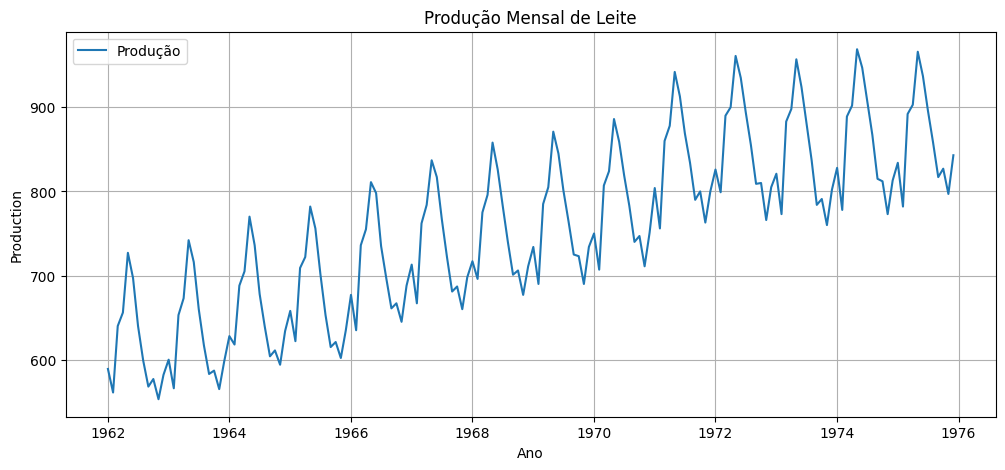

Tamanho total: 168
Tamanho treino: 144
Tamanho teste: 24


In [ ]:
# Célula corrigida: Upload, leitura robusta, pré-processamento e plot inicial
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1) Upload
uploaded = files.upload()

# 2) Leitura robusta do CSV (tenta usar sep=';', e se não funcionar, tenta dividir a única coluna)
for filename in uploaded.keys():
    try:
        df = pd.read_csv(filename, sep=';')
    except Exception as e:
        print(f"Leitura com sep=';' falhou: {e}. Tentando leitura padrão sem separador...")
        df = pd.read_csv(filename)

# 2.1) Caso o arquivo tenha sido lido como uma única coluna contendo ';', corrige isso:
if len(df.columns) == 1:
    col0 = df.columns[0]
    # tenta dividir a coluna pelo ';'
    maybe_split = df[col0].str.split(';', expand=True)
    if maybe_split.shape[1] >= 2:
        maybe_split.columns = ['Date', 'Production'][:maybe_split.shape[1]]
        df = maybe_split
        print("Arquivo lido como única coluna — realizei split por ';' com sucesso.")
    else:
        print("Atenção: arquivo com única coluna e split por ';' não produziu duas colunas. Verifique o CSV.")

# 3) Mostrar colunas detectadas e prévia
print("Colunas detectadas:", df.columns.tolist())
print("\nPrévia original (primeiras linhas):")
print(df.head())

# 4) Normalizar nomes de coluna (tornar strings consistentes)
df.columns = [str(c).strip() for c in df.columns]

# 5) Encontrar coluna de data e de produção (tolerante a variações)
date_col = None
prod_col = None
for c in df.columns:
    low = c.lower()
    if 'date' in low or 'month' in low or 'mes' in low:
        date_col = c
    if 'prod' in low or 'production' in low or 'milk' in low:
        prod_col = c

if date_col is None or prod_col is None:
    raise KeyError(f"Não foi possível identificar colunas 'Date' e/ou 'Production'. Detectadas: {df.columns.tolist()}")

# 6) Converter coluna de produção para numérico (limpar possíveis espaços)
df[prod_col] = df[prod_col].astype(str).str.strip().str.replace(',', '')  # remove vírgulas caso existam
df[prod_col] = pd.to_numeric(df[prod_col], errors='coerce')

# 7) Converter coluna de data para datetime (aceita formatos 'YYYY-MM' e similares)
try:
    df[date_col] = pd.to_datetime(df[date_col], format='%Y-%m')
except Exception:
    try:
        df[date_col] = pd.to_datetime(df[date_col])
    except Exception as e:
        raise ValueError(f"Falha ao converter a coluna de datas: {e}")

# 8) Definir índice temporal e ordenar por data
df.set_index(date_col, inplace=True)
df.sort_index(inplace=True)

# 9) Remover linhas com valores NaN na produção (se houver)
na_count = df[prod_col].isna().sum()
if na_count > 0:
    print(f"Atenção: {na_count} linhas com Production NaN foram removidas.")
    df = df[df[prod_col].notna()]

# 10) Mostrar prévia pós-processamento
print("\nPrévia pós-processamento:")
print(df.head())
print("\nInformações do índice (datas):", df.index.min(), "até", df.index.max())

# 11) Plot inicial
plt.figure(figsize=(12,5))
plt.plot(df[prod_col], label='Produção')
plt.title("Produção Mensal de Leite")
plt.xlabel("Ano")
plt.ylabel("Production")
plt.grid(True)
plt.legend()
plt.show()

# 12) Normalização e divisão treino/teste
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[[prod_col]])  # manter como DataFrame 2D

train_size = len(data_scaled) - 24
if train_size <= 0:
    raise ValueError("Dataset muito pequeno — não é possível reservar 24 meses para teste. Verifique os dados.")

train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

print(f"Tamanho total: {len(data_scaled)}")
print(f"Tamanho treino: {len(train_data)}")
print(f"Tamanho teste: {len(test_data)}")


In [ ]:
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        end_ix = i + n_steps
        seq_x, seq_y = data[i:end_ix], data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)


--- Treinando com janela (n_steps) = 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


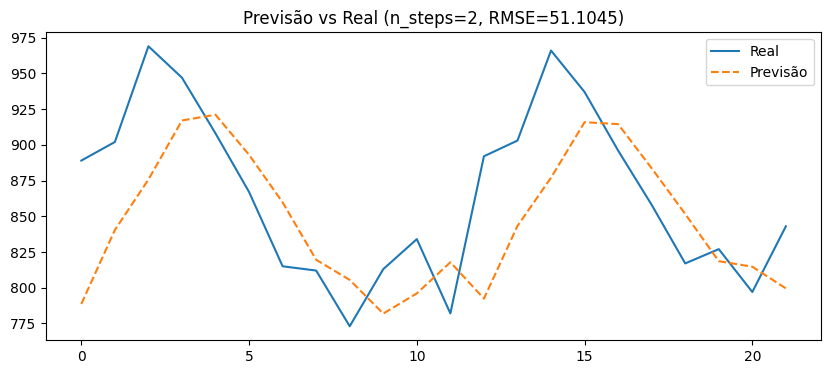

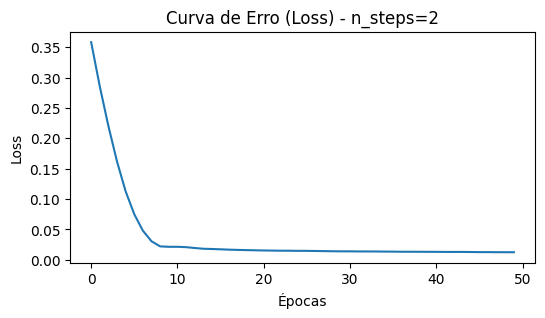

--- Treinando com janela (n_steps) = 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step


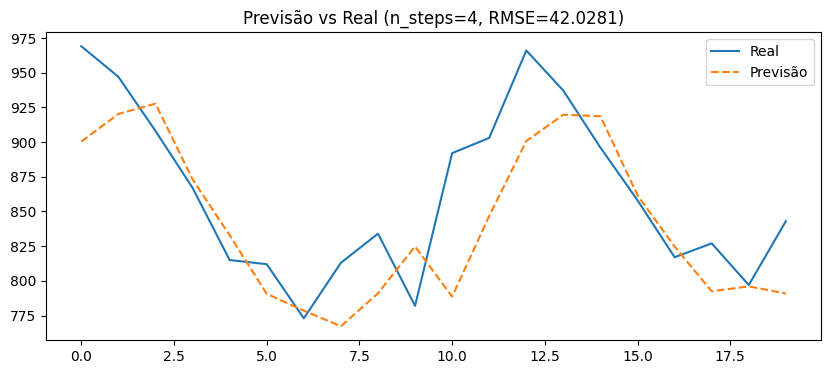

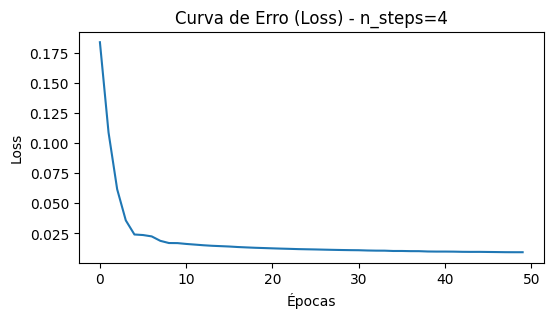

--- Treinando com janela (n_steps) = 6 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


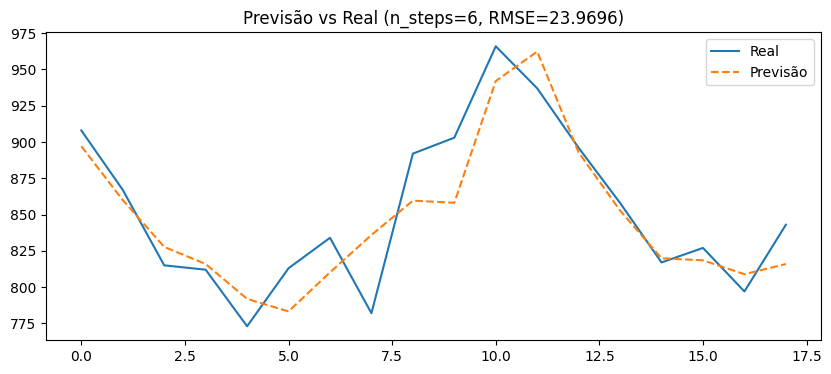

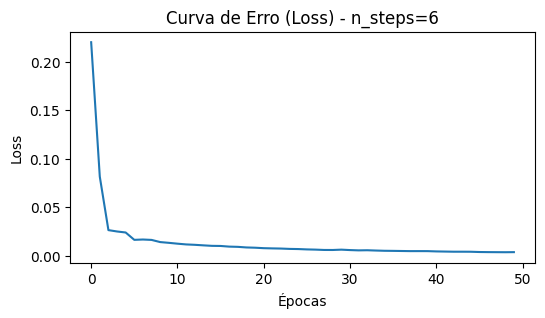


--- Resumo dos Resultados ---
Janela de Tempo = 2 | RMSE = 51.1045
Janela de Tempo = 4 | RMSE = 42.0281
Janela de Tempo = 6 | RMSE = 23.9696


In [ ]:
# Testar diferentes janelas de tempo
time_steps_list = [2, 4, 6]
results = {}
n_features = 1

for n_steps in time_steps_list:
    print(f"--- Treinando com janela (n_steps) = {n_steps} ---")

    X_train, y_train = create_sequences(train_data, n_steps)
    X_test, y_test = create_sequences(test_data, n_steps)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], n_features))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], n_features))

    model = Sequential()
    model.add(SimpleRNN(50, activation='relu', input_shape=(n_steps, n_features)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')

    history = model.fit(X_train, y_train, epochs=50, verbose=0)

    predictions_scaled = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions_scaled)
    y_test_real = scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_real, predictions))
    results[n_steps] = rmse

    plt.figure(figsize=(10,4))
    plt.title(f"Previsão vs Real (n_steps={n_steps}, RMSE={rmse:.4f})")
    plt.plot(y_test_real, label='Real')
    plt.plot(predictions, label='Previsão', linestyle='--')
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,3))
    plt.title(f"Curva de Erro (Loss) - n_steps={n_steps}")
    plt.plot(history.history['loss'])
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.show()

print("\n--- Resumo dos Resultados ---")
for n_steps, rmse in results.items():
    print(f"Janela de Tempo = {n_steps} | RMSE = {rmse:.4f}")


In [ ]:
from IPython.display import Markdown, display

md = """
# 🧠 Análise de Séries Temporais com Rede Neural Recorrente (RNN)
## Estudo de Caso: Produção Mensal de Leite (1962–1975)

### 1️⃣ Importação e Preparação dos Dados
Inicialmente foram importadas bibliotecas para manipulação e visualização de dados (`pandas`, `numpy`, `matplotlib`), normalização (`MinMaxScaler`) e construção do modelo (`TensorFlow/Keras`).

Os dados de produção de leite foram carregados a partir de um arquivo CSV, com as colunas:
- **Date**: mês/ano de observação;
- **Production**: produção mensal de leite (em libras).

A coluna de data foi convertida para o tipo `datetime` e usada como índice para representar a série temporal.

### 2️⃣ Normalização dos Dados
A normalização entre 0 e 1 foi feita com o `MinMaxScaler` para facilitar o aprendizado da rede neural, evitando que valores grandes distorcessem o cálculo dos gradientes.

Em seguida, o dataset foi dividido em:
- **Treinamento**: todos os meses menos os últimos 24;
- **Teste**: últimos 24 meses (2 anos), usados para avaliar o modelo.

### 3️⃣ Criação das Sequências Temporais
A função `create_sequences(data, n_steps)` gera janelas deslizantes de observações:
- Para cada ponto, usa os `n_steps` anteriores como entrada (`X`);
- O valor seguinte é a saída esperada (`y`).

Esse formato é essencial para RNNs, que aprendem padrões temporais em sequências.

### 4️⃣ Estrutura da Rede Neural Recorrente (SimpleRNN)
A rede foi criada com o modelo `Sequential`, composta por:
- **Camada SimpleRNN** com 50 neurônios e ativação ReLU;
- **Camada Dense (saída)** com 1 neurônio, responsável por prever o próximo valor da série.

O modelo foi compilado com:
- **Otimizador**: Adam (ajuste adaptativo da taxa de aprendizado);
- **Função de perda (loss)**: Mean Squared Error (erro quadrático médio).

### 5️⃣ Treinamento e Avaliação
O modelo foi treinado por 50 épocas para diferentes tamanhos de janela (`n_steps = 2, 4, 6`).
Após o treino:
- As previsões foram **desnormalizadas**;
- O erro foi avaliado com **RMSE** (Root Mean Squared Error);
- Foram gerados **gráficos de comparação** (valores reais vs previstos);
- E o **histórico de perda (loss)** ao longo das épocas.

### 6️⃣ Análise Crítica
- **Com janelas menores (2 passos)**: o modelo captura menos dependências temporais -> previsões menos suaves e RMSE mais alto.
- **Com janelas médias (4 passos)**: há equilíbrio entre precisão e custo computacional.
- **Com janelas longas (6 ou mais)**: o modelo tende a aprender melhor o padrão da série, mas pode superajustar (overfitting).

O gráfico de `loss` mostra a convergência do modelo e ajuda a identificar se o treinamento foi adequado.

---

### 📈 Conclusão
O uso de redes **SimpleRNN** mostrou-se eficiente para prever tendências em séries temporais simples como a produção de leite.
A escolha do **tamanho da janela temporal** impacta diretamente na **precisão** e na **estabilidade do erro (loss)**.

Modelos mais sofisticados como **LSTM** ou **GRU** podem melhorar os resultados ao lidar com dependências de longo prazo e reduzir o erro de previsão.

---

🧑‍🏫 *Atividade baseada na disciplina de Redes Neurais, Prof. Dr. Cleber Gustavo Dias e Prof. Dr. Wonder Alexandre Luz Alves.*
"""

display(Markdown(md))



# 🧠 Análise de Séries Temporais com Rede Neural Recorrente (RNN)
## Estudo de Caso: Produção Mensal de Leite (1962–1975)

### 1️⃣ Importação e Preparação dos Dados
Inicialmente foram importadas bibliotecas para manipulação e visualização de dados (`pandas`, `numpy`, `matplotlib`), normalização (`MinMaxScaler`) e construção do modelo (`TensorFlow/Keras`).

Os dados de produção de leite foram carregados a partir de um arquivo CSV, com as colunas:
- **Date**: mês/ano de observação;
- **Production**: produção mensal de leite (em libras).

A coluna de data foi convertida para o tipo `datetime` e usada como índice para representar a série temporal.

### 2️⃣ Normalização dos Dados
A normalização entre 0 e 1 foi feita com o `MinMaxScaler` para facilitar o aprendizado da rede neural, evitando que valores grandes distorcessem o cálculo dos gradientes.

Em seguida, o dataset foi dividido em:
- **Treinamento**: todos os meses menos os últimos 24;
- **Teste**: últimos 24 meses (2 anos), usados para avaliar o modelo.

### 3️⃣ Criação das Sequências Temporais
A função `create_sequences(data, n_steps)` gera janelas deslizantes de observações:
- Para cada ponto, usa os `n_steps` anteriores como entrada (`X`);
- O valor seguinte é a saída esperada (`y`).

Esse formato é essencial para RNNs, que aprendem padrões temporais em sequências.

### 4️⃣ Estrutura da Rede Neural Recorrente (SimpleRNN)
A rede foi criada com o modelo `Sequential`, composta por:
- **Camada SimpleRNN** com 50 neurônios e ativação ReLU;
- **Camada Dense (saída)** com 1 neurônio, responsável por prever o próximo valor da série.

O modelo foi compilado com:
- **Otimizador**: Adam (ajuste adaptativo da taxa de aprendizado);
- **Função de perda (loss)**: Mean Squared Error (erro quadrático médio).

### 5️⃣ Treinamento e Avaliação
O modelo foi treinado por 50 épocas para diferentes tamanhos de janela (`n_steps = 2, 4, 6`).
Após o treino:
- As previsões foram **desnormalizadas**;
- O erro foi avaliado com **RMSE** (Root Mean Squared Error);
- Foram gerados **gráficos de comparação** (valores reais vs previstos);
- E o **histórico de perda (loss)** ao longo das épocas.

### 6️⃣ Análise Crítica
- **Com janelas menores (2 passos)**: o modelo captura menos dependências temporais -> previsões menos suaves e RMSE mais alto.
- **Com janelas médias (4 passos)**: há equilíbrio entre precisão e custo computacional.
- **Com janelas longas (6 ou mais)**: o modelo tende a aprender melhor o padrão da série, mas pode superajustar (overfitting).

O gráfico de `loss` mostra a convergência do modelo e ajuda a identificar se o treinamento foi adequado.

---

### 📈 Conclusão
O uso de redes **SimpleRNN** mostrou-se eficiente para prever tendências em séries temporais simples como a produção de leite.  
A escolha do **tamanho da janela temporal** impacta diretamente na **precisão** e na **estabilidade do erro (loss)**.

Modelos mais sofisticados como **LSTM** ou **GRU** podem melhorar os resultados ao lidar com dependências de longo prazo e reduzir o erro de previsão.

---

🧑‍🏫 *Atividade baseada na disciplina de Redes Neurais, Prof. Dr. Cleber Gustavo Dias e Prof. Dr. Wonder Alexandre Luz Alves.*
